In [1]:
#Bibliotecas de manipualção e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

#Classes do modelo de aprendizado
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

#Funções de avaliação dos modelos
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Classificacao

In [2]:
#Carregando o dataset
dataset = pd.read_csv("Datasets/Iris.csv")
# Mapeando os valores da classe para inteiro (para fins de visualização da região de decisão)
dataset['Species'] = pd.factorize(dataset['Species'])[0]

In [3]:
#Vamos usar somente duas features SepalLengthCm e SepalWidthCm
X = dataset.iloc[:,[0,1]]
y = dataset.iloc[:,[4]]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [4]:
model = DecisionTreeClassifier()
#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

#Resultados do classificador
print(classification_report(y_test, y_pred))
     

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.69      0.60      0.64        15
           2       0.50      0.67      0.57         9

    accuracy                           0.74        38
   macro avg       0.73      0.73      0.73        38
weighted avg       0.76      0.74      0.74        38



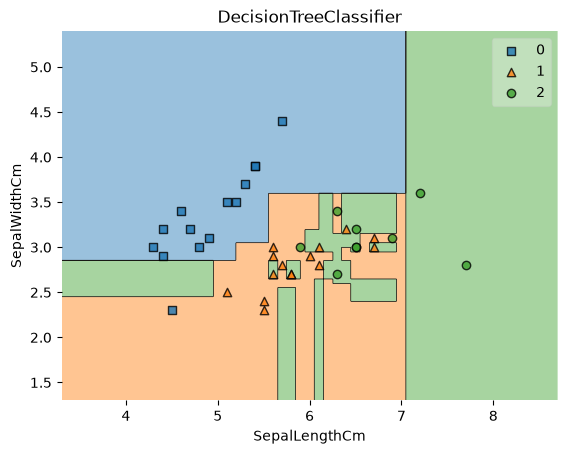

In [5]:
def show_decision_region(x, y, clf):
    plot_decision_regions(x, y, clf=clf)
    plt.xlabel("SepalLengthCm")
    plt.ylabel("SepalWidthCm")

    plt.title(clf.__class__.__name__)
    plt.savefig("imagens/decision_region.png", dpi=200, bbox_inches="tight")
    plt.show()

show_decision_region(np.array([X_test["SepalLengthCm"].values, X_test["SepalWidthCm"].values]).T, y_test.values.reshape(-1,1).T[0], model)

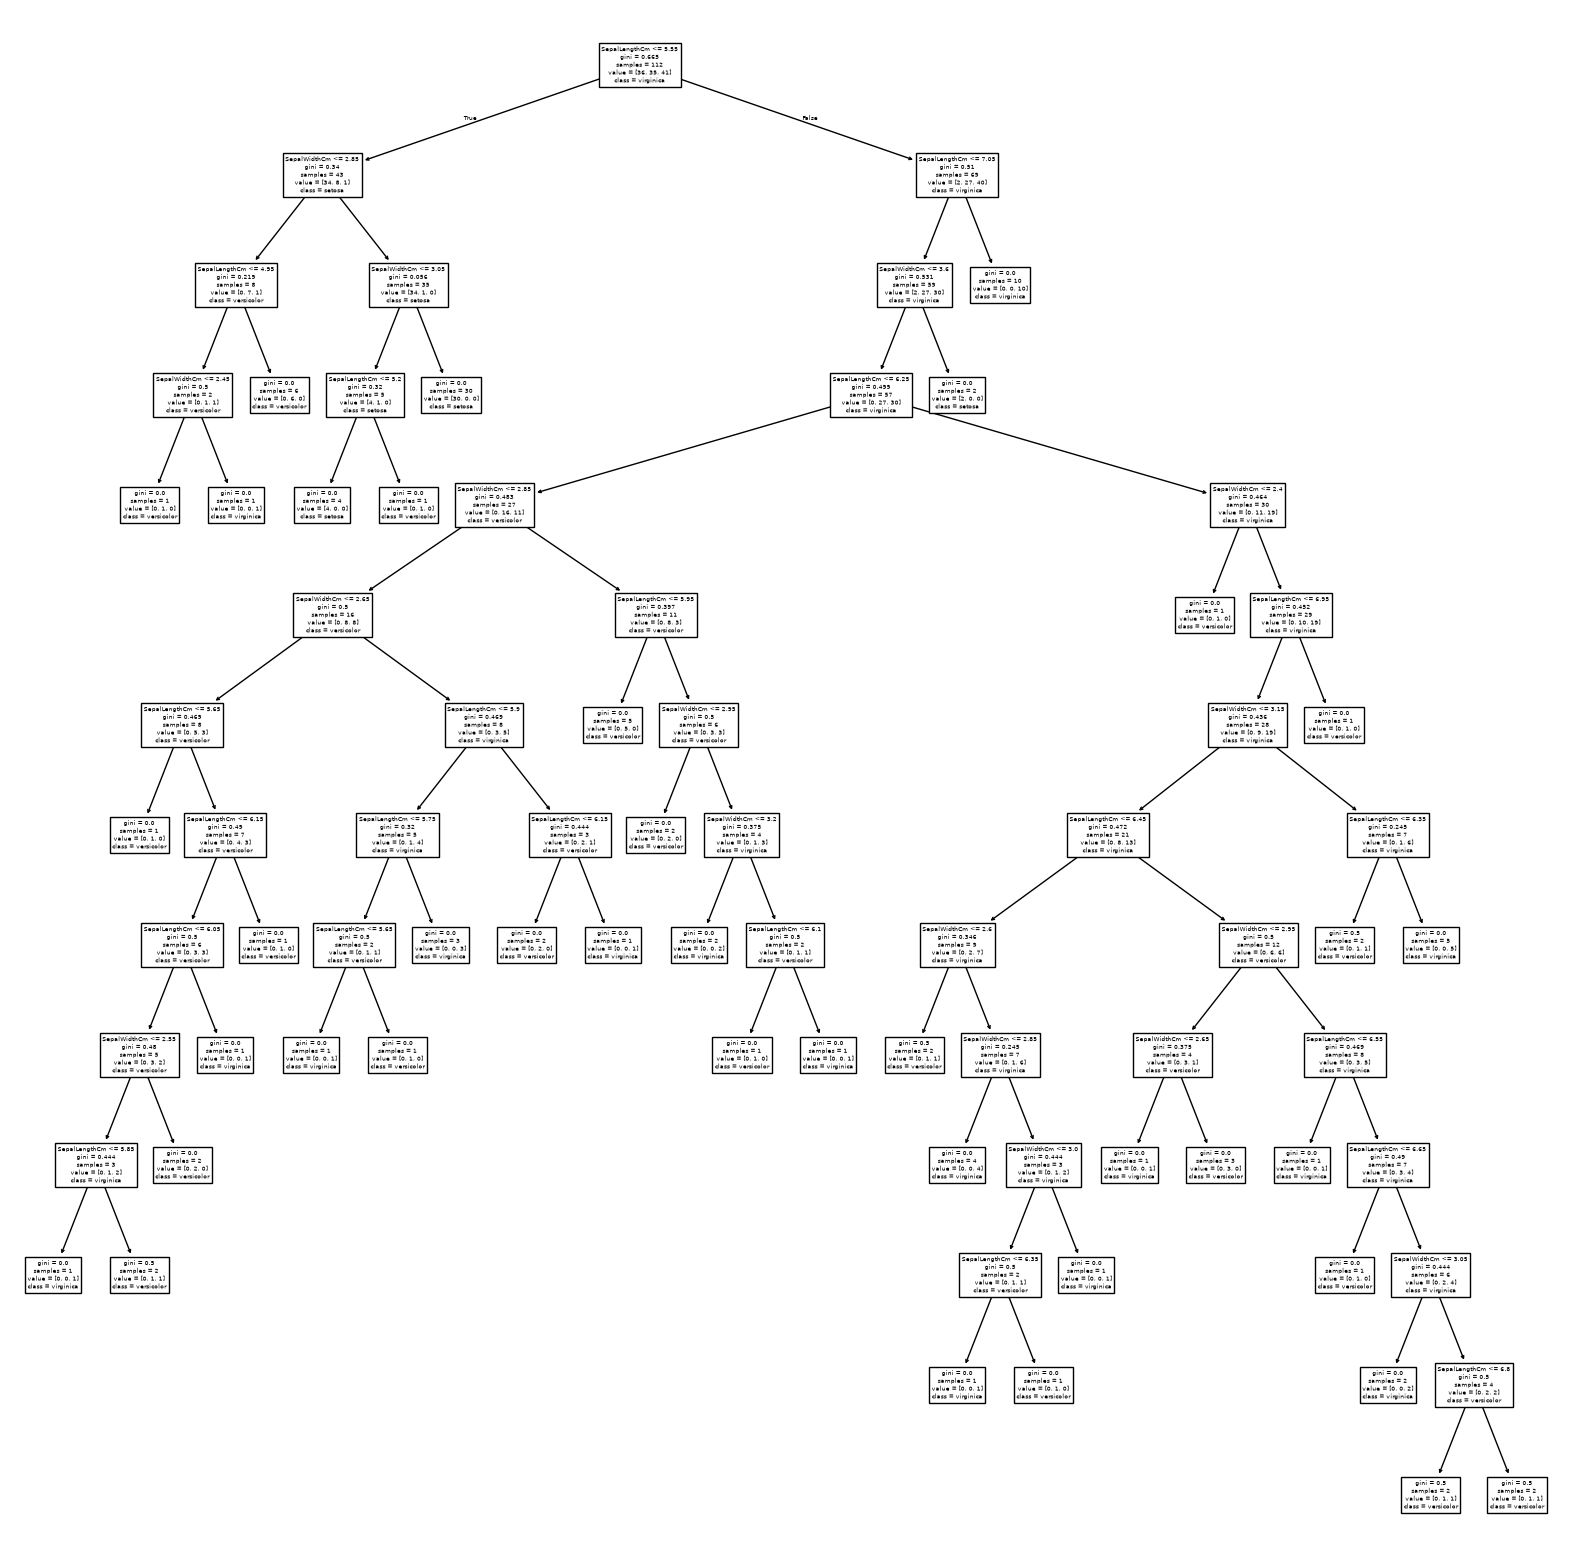

In [6]:
plt.figure(figsize=(20,20))
plot_tree(model, feature_names=["SepalLengthCm", "SepalWidthCm"], class_names=['setosa', 'versicolor', 'virginica'])
plt.savefig("imagens/arvore_2features.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
#com as 4 features
#Vamos usar todas as features
X = dataset.iloc[:,0:4]
y = dataset.iloc[:,-1]
# y = dataset.loc[:,["Species"]]

#Separando o conjunto de dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [8]:
model = DecisionTreeClassifier()
#treinando o modelo
model.fit(X_train, y_train)

#predição
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.83      0.83        12
           2       0.86      0.86      0.86        14

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.89      0.89      0.89        38



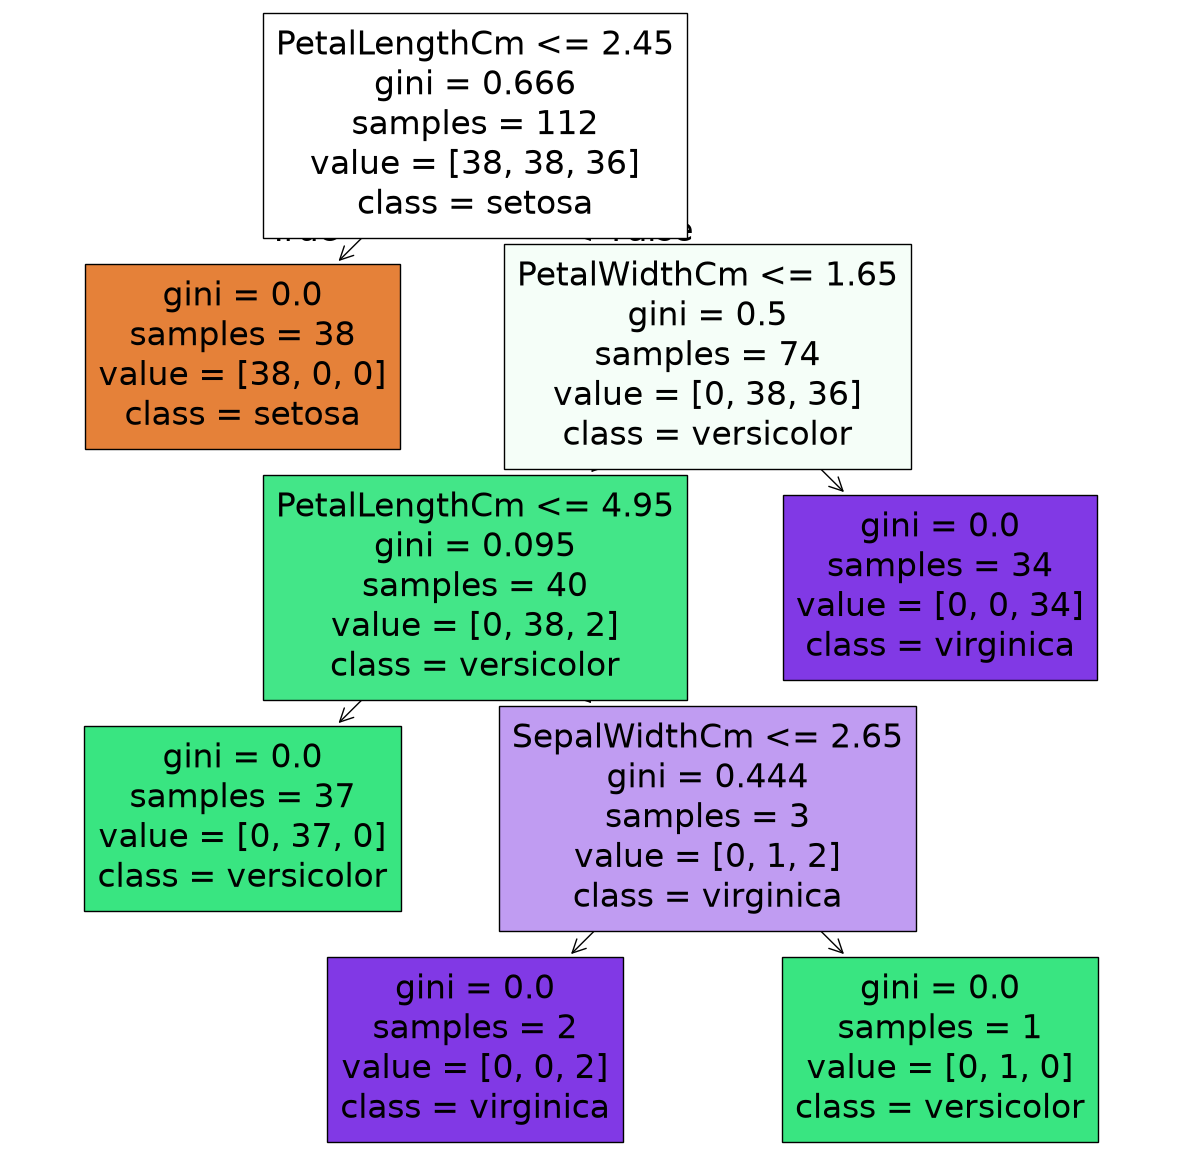

In [9]:
plt.figure(figsize=(15,15))
tree = plot_tree(model, feature_names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"], 
                 class_names=['setosa', 'versicolor', 'virginica'], filled=True)
plt.savefig("imagens/arvore_4features.png", dpi=200, bbox_inches="tight")
plt.show()

**Criterion** é a função para medir a qualidade de uma divisão. Por padrão o critério usado é o coeficiente gini [Link](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier).

- coeficiente gini: Mede a probabilidade de uma variável específica ser classificada erroneamente quando escolhida aleatoriamente. $gini(p) = 1-\sum_{i=1}^n (p_i)^2$

- entropia: Entropia é o grau de incerteza, impureza ou desordem de uma variável aleatória ou uma medida de pureza.  

In [10]:
for i, criterion in enumerate(['gini', 'entropy']):
    print(criterion.upper()+ "\n")
    model = DecisionTreeClassifier(criterion=criterion, max_depth=4)
    #treinando o modelo
    model.fit(X_train, y_train)    
    
    #predição
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))
    
plt.show()

GINI

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.83      0.83        12
           2       0.86      0.86      0.86        14

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.89      0.89      0.89        38

ENTROPY

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.83      0.83        12
           2       0.86      0.86      0.86        14

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.89      0.89      0.89        38



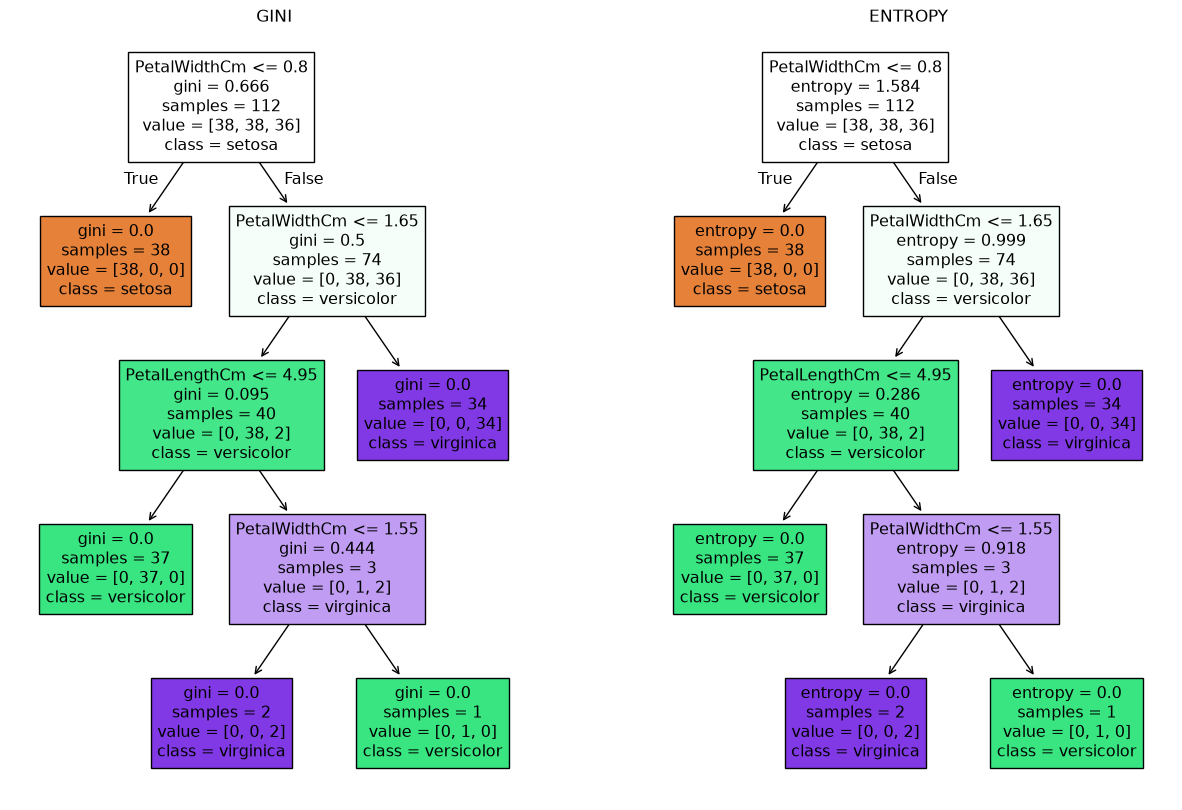

In [11]:
fig, ax = plt.subplots(1,2, figsize=(15,10))

for i, criterion in enumerate(['gini', 'entropy']):
    model = DecisionTreeClassifier(criterion=criterion, max_depth=4)
    #treinando o modelo
    model.fit(X_train, y_train)    
    
    tree = plot_tree(model, ax=ax[i],feature_names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
                 class_names=['setosa', 'versicolor', 'virginica'], filled=True)
    ax[i].set_title(criterion.upper())
plt.savefig("imagens/arvore_gini_entropy.png", dpi=200, bbox_inches="tight")
plt.show()

**max_depth** determina a profundidade máxima da árvore

In [12]:
for i, max_depth in enumerate([2,3,4]):
    print(f"MAX_DEPTH - {max_depth} \n ")
    model = DecisionTreeClassifier(max_depth=max_depth)
    #treinando o modelo
    model.fit(X_train, y_train)    
    
    #predição
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))
    
plt.show()

MAX_DEPTH - 2 
 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.83      0.83        12
           2       0.86      0.86      0.86        14

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.89      0.89      0.89        38

MAX_DEPTH - 3 
 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.83      0.91        12
           2       0.88      1.00      0.93        14

    accuracy                           0.95        38
   macro avg       0.96      0.94      0.95        38
weighted avg       0.95      0.95      0.95        38

MAX_DEPTH - 4 
 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.83      0.83      0.83        12
           2       0.86 

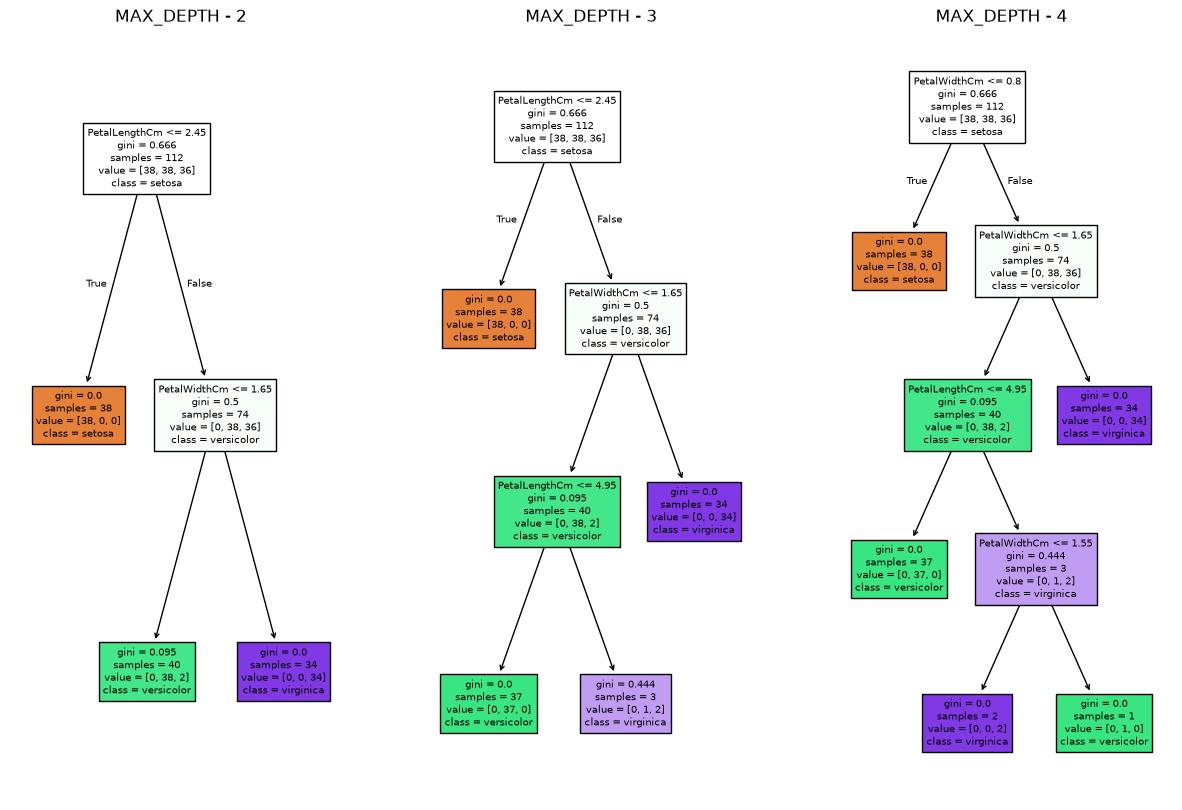

In [13]:
fig, ax = plt.subplots(1,3, figsize=(15,10))

for i, max_depth in enumerate([2,3,4]):
    model = DecisionTreeClassifier(max_depth=max_depth)
    #treinando o modelo
    model.fit(X_train, y_train)    
    
    tree = plot_tree(model, ax=ax[i],feature_names=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
                 class_names=['setosa', 'versicolor', 'virginica'], filled=True)
    ax[i].set_title(f"MAX_DEPTH - {max_depth}")

plt.savefig("imagens/arvore_max_depth.png", dpi=200, bbox_inches="tight")
plt.show()

[Clique aqui e divirta-se!](https://decisiontree-visualizer.streamlit.app/)

## Regressão

Em vez de criar nós que deixem as classes mais “puras”, esta adaptação procura criar grupos em que os valores da variável-alvo y sejam o mais semelhantes possível.

[**Dataset House**](https://www.openml.org/search?type=data&id=574&sort=runs&status=active)

Este banco de dados foi construído com base em dados fornecidos pelo US Census Bureau (Departamento do Censo dos Estados Unidos), coletados durante o Censo dos Estados Unidos de 1990. O objetivo é prever o preço mediano das casas em uma determinada região, utilizando como variáveis de entrada informações sobre a composição demográfica e a situação do mercado imobiliário da região:

| Coluna | Significado |
|---|---|
| Price | Preço médio dos imóveis na região (variável-alvo) |
| P1 | Número total de pessoas na região |
| P5p1 | Percentual de homens |
| P6p2 | Percentual de pessoas negras |
| P11p4 | Percentual de pessoas com mais de 64 anos |
| P14p9 | Percentual de mulheres viúvas |
| P15p1 | Percentual de pessoas em domicílios familiares |
| P15p3 | Percentual de pessoas em alojamentos coletivos (incl. prisões) |
| P16p2 | Percentual de domicílios com 2+ pessoas que são domicílios familiares |
| P18p2 | Percentual de domicílios com 1+ pessoa menor de 18 anos que são domicílios não familiares |
| P27p4 | Percentual de domicílios não familiares com 2+ pessoas |
| H2p2 | Percentual de unidades habitacionais vagas (desocupadas) |
| H8p2 | Percentual de unidades habitacionais ocupadas com responsável negro |
| H10p1 | Percentual de unidades habitacionais ocupadas com responsável não hispânico |
| H13p1 | Percentual de unidades habitacionais com 1 a 4 cômodos |
| H18pA | Número médio de pessoas por unidade habitacional ocupada pelo proprietário |
| H40p4 | Percentual de unidades vagas para venda há mais de 6 meses |


In [14]:
dataset_R = pd.read_csv("Datasets/house.csv")


In [15]:
dataset_R.head()

,Price,P1,P5p1,P6p2,P11p4,P14p9,P15p1,P15p3,P16p2,P18p2,P27p4,H2p2,H8p2,H10p1,H13p1,H18pA,H40p4
0,14999,219,0.506849,0.031963,0.146119,0.101852,0.876712,0.000000,0.746988,0.012048,0.060241,0.231482,0.024096,0.987952,0.351852,0.000000,0.800000
1,106200,2273,0.495381,0.018918,0.067312,0.045336,0.794545,0.016718,0.641053,0.002105,0.076842,0.064961,0.017895,0.997895,0.170276,0.054217,0.258064
2,14999,564,0.457447,0.058511,0.299645,0.238562,0.764184,0.010638,0.567273,0.003636,0.014545,0.140625,0.054545,0.996364,0.381250,0.056180,1.000000
3,29900,620,0.495161,0.003226,0.104839,0.086262,0.909677,0.000000,0.792793,0.009009,0.027027,0.051282,0.004504,0.995495,0.183761,0.162791,0.000000
4,85900,3809,0.491730,0.205303,0.107115,0.085744,0.899449,0.000000,0.766566,0.008283,0.039910,0.017024,0.200301,0.985693,0.198372,0.106557,0.666667


In [16]:
X = dataset_R.iloc[:,1:-1] 
y = dataset_R.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X,y)

In [17]:
regression_tree = DecisionTreeRegressor(max_depth=6)
regression_tree.fit(X_train, y_train)

y_pred = regression_tree.predict(X_test)

#Coeficiente de determinação - melhor valor é 1
print("R2_score:", r2_score(y_test, y_pred))

R2_score: 0.39613336444156655


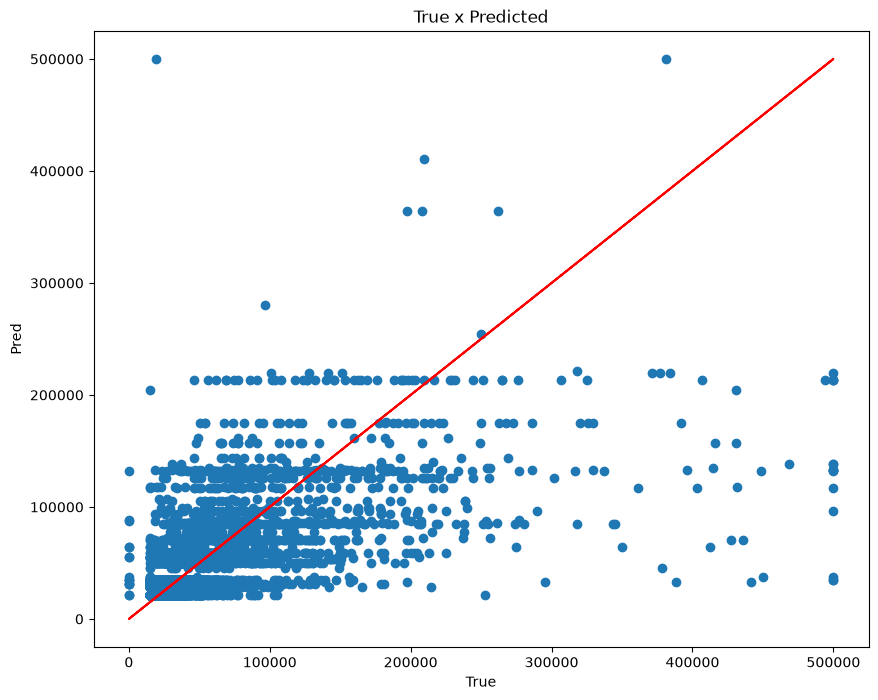

In [18]:
plt.figure(figsize=(10,8))
ax = plt.axes()
ax.scatter(y_test, y_pred)
ax.plot(y_test, y_test, color='red')

ax.set_xlabel('True')
ax.set_ylabel('Pred')
plt.title("True x Predicted")

plt.savefig("imagens/regressao_true_x_pred.png", dpi=200, bbox_inches="tight")
plt.show()

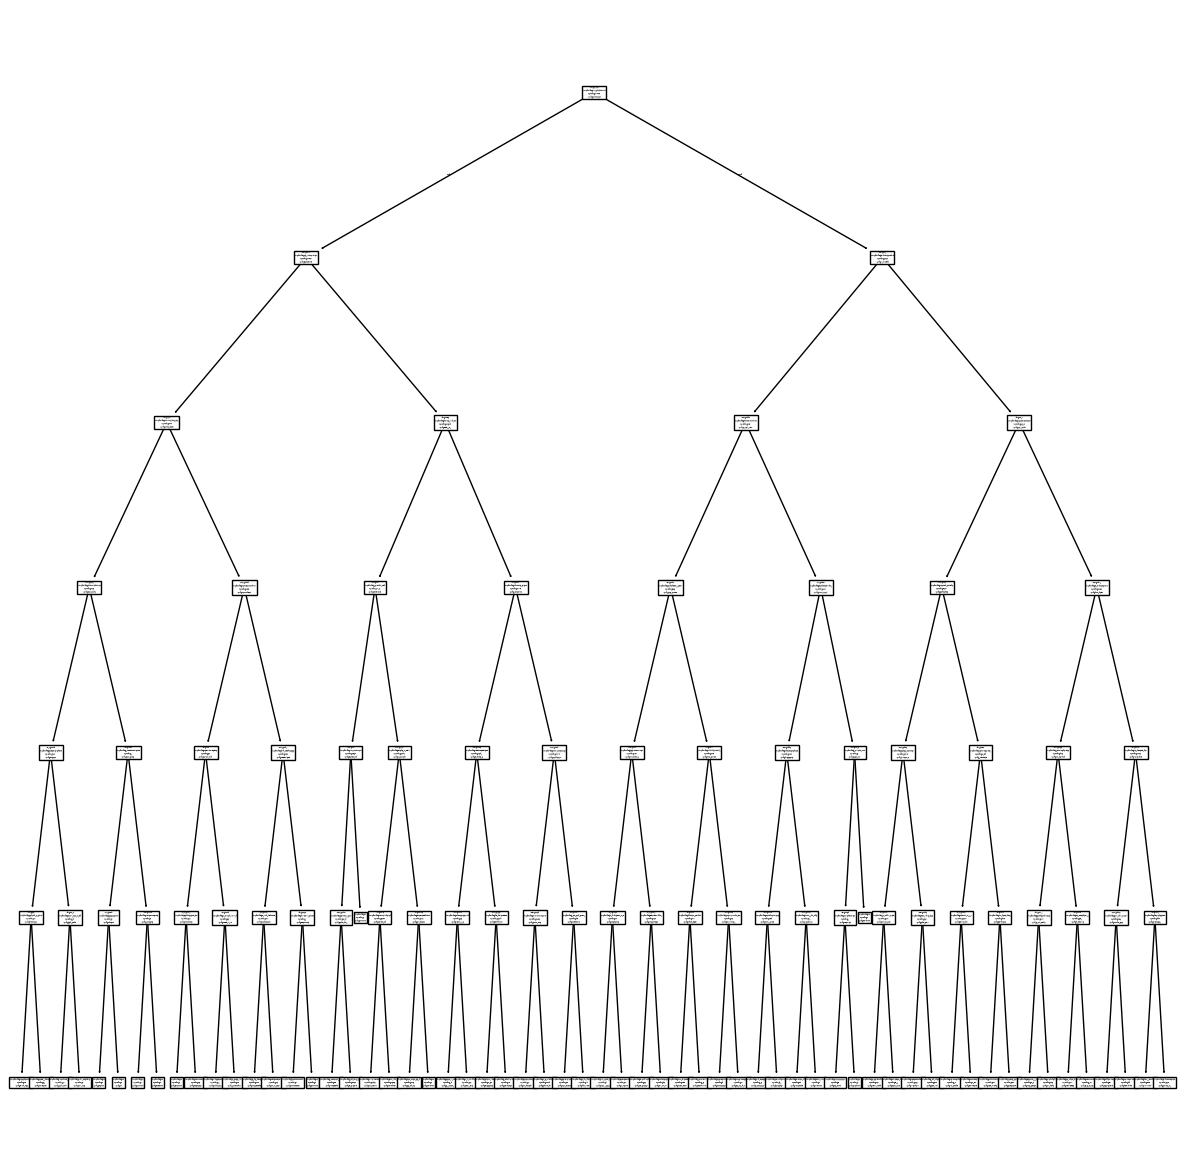

In [19]:
plt.figure(figsize=(15,15))
_ = plot_tree(regression_tree)
plt.savefig("imagens/arvore_regressao.png", dpi=300, bbox_inches="tight")
plt.show()